# Q2 · Does solar cannibalise its own value?

When many solar panels produce at the same time, they push the price down in exactly the hours they sell.
The **capture price** is what one MWh of solar actually earned on the day-ahead market (price weighted by solar
output); the **capture rate** divides it by the average (baseload) price. A rate of 100% means solar earns the
average price; below 100% means its value is being eroded.

Reads the dbt mart `fct_capture_prices` ([ADR-006](../control-room/04%20Decisions/ADR-006%20Hourly%20Grid%20and%20Capture%20Prices.md)):
prices and generation on one hourly grid, local calendar years, partial years flagged as in Q1.

**Data caveat.** Generation is *as reported to ENTSO-E*. In the Netherlands that series holds only ~2% of the
country's solar output (0.49 TWh in 2024 vs 22 TWh in CBS statistics), so NL's solar share is not usable and its
capture rate is indicative only. Polish solar is reported from April 2020, so PL solar starts in 2021.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

import chart_style as cs

cs.apply_style()

with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    q2 = con.sql("select * from fct_capture_prices order by zone, local_year").df()
    ytd_end = con.sql(
        "select max(hour_local) + interval 1 hour from int_energy_hourly where local_year = 2026"
    ).fetchone()[0]

YTD_LABEL = f"1 Jan to {(ytd_end - pd.Timedelta(minutes=1)):%-d %b} 2026"
CURRENT_YEAR = 2026
NL_NOTE = "ENTSO-E covers ~2% of Dutch solar"
pct = mticker.PercentFormatter(1.0, decimals=0)
print("2026 year to date:", YTD_LABEL)
q2[["zone", "local_year", "baseload_price", "solar_capture_price", "solar_capture_rate", "solar_share",
    "wind_capture_rate", "wind_share", "coverage", "is_partial_year", "partial_reason"]]

2026 year to date: 1 Jan to 3 Oct 2026


,zone,local_year,baseload_price,solar_capture_price,solar_capture_rate,solar_share,wind_capture_rate,wind_share,coverage,is_partial_year,partial_reason
0,BE,2019,39.35,36.23,0.9208,0.0403,0.9104,0.0918,0.9999,False,NaN
1,BE,2020,31.88,24.61,0.7719,0.0514,0.9321,0.1324,1.0000,False,NaN
2,BE,2021,104.12,76.78,0.7374,0.0501,0.9053,0.1153,1.0000,False,NaN
3,BE,2022,244.53,225.02,0.9202,0.0715,0.7707,0.1213,1.0000,False,NaN
4,BE,2023,97.27,76.21,0.7835,0.0901,0.8489,0.1772,1.0000,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
59,PT,2022,167.87,150.95,0.8992,0.0574,0.9446,0.2935,1.0000,False,NaN
60,PT,2023,88.28,73.02,0.8272,0.0812,0.8695,0.2925,1.0000,False,NaN
61,PT,2024,63.46,42.71,0.6730,0.1072,0.8706,0.3088,1.0000,False,NaN
62,PT,2025,66.18,35.34,0.5340,0.1246,0.9167,0.2753,1.0000,False,NaN


## Chart 1 · Solar capture rate per zone and year
Panels are ordered by the 2025 capture rate (most eroded first). 2026 is year to date and drawn hollow.
Poland 2019 and 2020 have no solar data; Poland 2019 is also a partial price year.

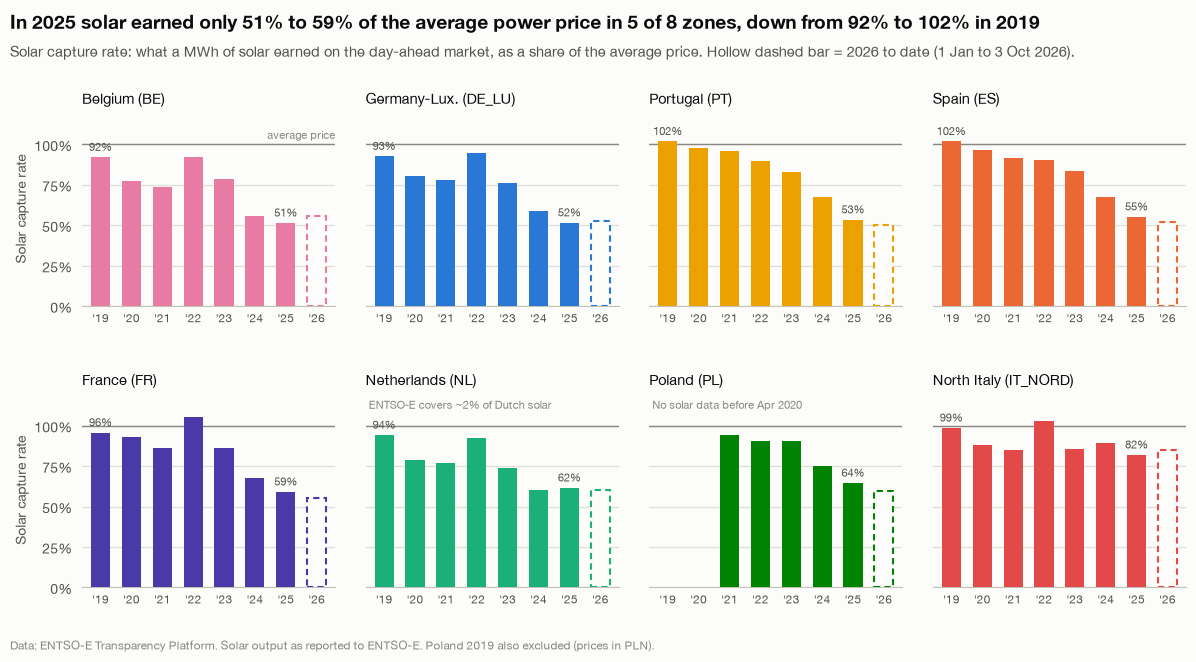

In [2]:
c1 = q2[(~q2.is_partial_year) | (q2.partial_reason == "current_year")]
order = c1[c1.local_year == 2025].sort_values("solar_capture_rate").zone.tolist()
years = list(range(2019, CURRENT_YEAR + 1))

fig, axes = plt.subplots(2, 4, figsize=(12, 6.6), sharey=True)
fig.subplots_adjust(left=0.07, right=0.99, top=0.83, bottom=0.11, hspace=0.45, wspace=0.12)
for ax, zone in zip(axes.flat, order):
    color = cs.ZONE_COLORS[zone]
    z = c1[c1.zone == zone].set_index("local_year").reindex(years)
    ax.axhline(1.0, color=cs.INK_MUTED, lw=1, zorder=2)
    for year, rate in z.solar_capture_rate.items():
        if pd.isna(rate):
            continue
        if year == CURRENT_YEAR:
            ax.bar(year, rate, width=0.62, facecolor=cs.SURFACE, edgecolor=color,
                   linewidth=1.5, linestyle=(0, (3, 2)), zorder=3)
        else:
            ax.bar(year, rate, width=0.62, color=color, zorder=3)
    for year in (2019, 2025):
        rate = z.solar_capture_rate.get(year)
        if pd.notna(rate):
            ax.text(year, rate + 0.025, f"{rate:.0%}", ha="center", va="bottom", fontsize=8,
                    color=cs.INK_SECONDARY)
    note = {"NL": NL_NOTE, "PL": "No solar data before Apr 2020"}.get(zone)
    if note:
        ax.text(2018.5, 1.17, note, ha="left", va="top", fontsize=8, color=cs.INK_MUTED)
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})", loc="left", fontsize=10.5, color=cs.INK, pad=6)
    ax.set_xticks(years, [f"'{y % 100:02d}" for y in years])
    ax.tick_params(axis="x", length=0, labelsize=8.5)
    ax.set_xlim(years[0] - 0.6, years[-1] + 0.6)
    ax.set_ylim(0, 1.2)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(pct)
    ax.spines["bottom"].set_color(cs.AXIS)
axes[0, 0].text(2026.6, 1.02, "average price", ha="right", va="bottom", fontsize=8, color=cs.INK_MUTED)
for ax in axes[:, 0]:
    ax.set_ylabel("Solar capture rate")

y25 = c1[c1.local_year == 2025].set_index("zone").solar_capture_rate
y19 = c1[c1.local_year == 2019].set_index("zone").solar_capture_rate
low = y25[y25 < 0.6]
cs.add_title(
    fig,
    f"In 2025 solar earned only {low.min():.0%} to {low.max():.0%} of the average power price "
    f"in {len(low)} of 8 zones, down from {y19[low.index].min():.0%} to {y19[low.index].max():.0%} in 2019",
    "Solar capture rate: what a MWh of solar earned on the day-ahead market, as a share of the average price. "
    f"Hollow dashed bar = 2026 to date ({YTD_LABEL}).",
)
cs.add_source(fig, "Solar output as reported to ENTSO-E. Poland 2019 also excluded (prices in PLN).")
cs.save(fig, "q2_solar_capture_rate_by_zone")
plt.show()

## Chart 2 · The cannibalisation curve
Solar share of reported generation (x) against solar capture rate (y), one dot per zone and year, joined in time
order. Each panel highlights one zone; the other zones are drawn in grey for context. The Netherlands is left out:
its x value is wrong by a factor of ~45 (see caveat).

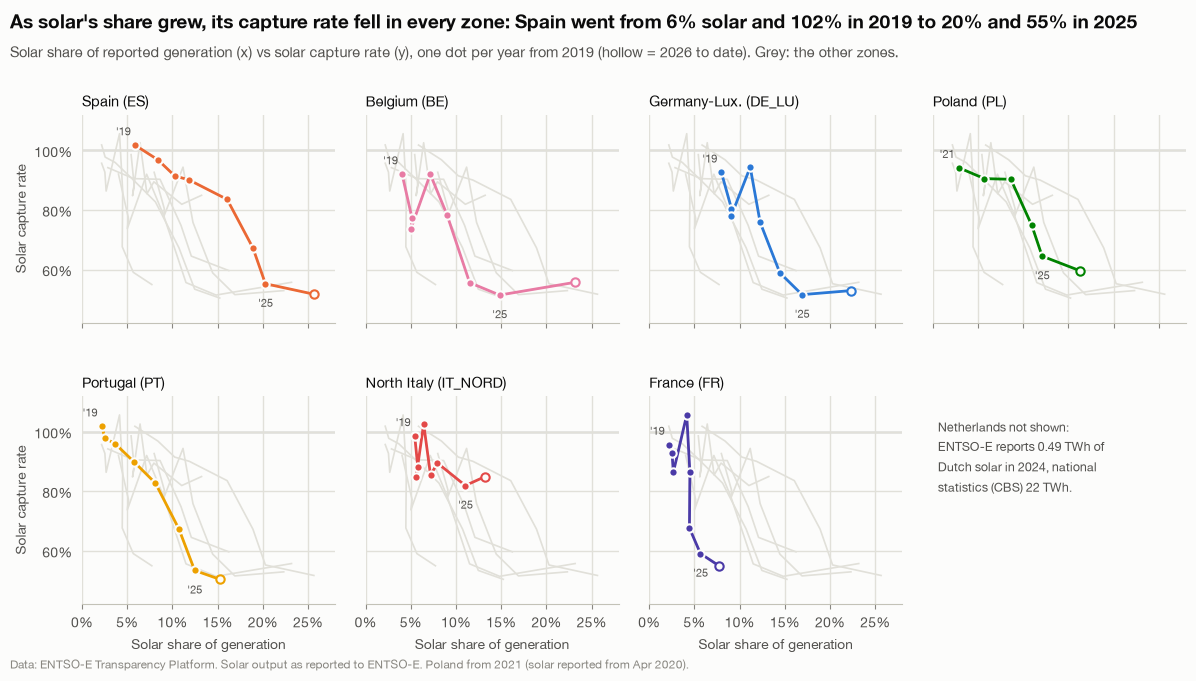

In [3]:
c2 = q2[((~q2.is_partial_year) | (q2.partial_reason == "current_year"))
        & q2.solar_capture_rate.notna() & (q2.zone != "NL")]
zones = c2.groupby("zone").solar_share.max().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(12, 6.8), sharex=True, sharey=True)
fig.subplots_adjust(left=0.07, right=0.99, top=0.83, bottom=0.11, hspace=0.35, wspace=0.12)
for ax, zone in zip(axes.flat, zones):
    for other in zones:  # context
        o = c2[c2.zone == other]
        ax.plot(o.solar_share, o.solar_capture_rate, color=cs.GRID, lw=1.2, zorder=1)
    z = c2[c2.zone == zone]
    full, ytd = z[z.local_year < CURRENT_YEAR], z[z.local_year == CURRENT_YEAR]
    color = cs.ZONE_COLORS[zone]
    ax.plot(z.solar_share, z.solar_capture_rate, color=color, lw=2, zorder=2)
    ax.scatter(full.solar_share, full.solar_capture_rate, s=36, color=color,
               edgecolor=cs.SURFACE, linewidth=1.5, zorder=3)
    ax.scatter(ytd.solar_share, ytd.solar_capture_rate, s=36, facecolor=cs.SURFACE,
               edgecolor=color, linewidth=1.5, zorder=3)
    # Label the first year (above left) and 2025 (below), away from the line.
    first, y2025 = z.iloc[0], z[z.local_year == 2025].iloc[0]
    ax.annotate(f"'{first.local_year % 100:02d}", (first.solar_share, first.solar_capture_rate),
                xytext=(-3, 7), textcoords="offset points", ha="right", fontsize=8, color=cs.INK_SECONDARY)
    ax.annotate("'25", (y2025.solar_share, y2025.solar_capture_rate), xytext=(0, -9),
                textcoords="offset points", ha="center", va="top", fontsize=8, color=cs.INK_SECONDARY)
    ax.axhline(1.0, color=cs.INK_MUTED, lw=1, zorder=0)
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})", loc="left", fontsize=10.5, color=cs.INK, pad=6)
    ax.grid(axis="x", color=cs.GRID, lw=1)
    ax.xaxis.set_major_formatter(pct)
    ax.yaxis.set_major_formatter(pct)
    ax.set_xlim(0, 0.28)
    ax.set_ylim(0.42, 1.12)
for ax in axes[:, 0]:
    ax.set_ylabel("Solar capture rate")
for ax in axes[1, :]:
    ax.set_xlabel("Solar share of generation")
last = axes.flat[len(zones)]
last.axis("off")
last.text(0.02, 0.9, "Netherlands not shown:\nENTSO-E reports 0.49 TWh of\nDutch solar in 2024, national\nstatistics (CBS) 22 TWh.",
          transform=last.transAxes, ha="left", va="top", fontsize=9, color=cs.INK_SECONDARY, linespacing=1.4)

es = c2[c2.zone == "ES"].set_index("local_year")
cs.add_title(
    fig,
    "As solar's share grew, its capture rate fell in every zone: Spain went from "
    f"{es.solar_share[2019]:.0%} solar and {es.solar_capture_rate[2019]:.0%} in 2019 "
    f"to {es.solar_share[2025]:.0%} and {es.solar_capture_rate[2025]:.0%} in 2025",
    "Solar share of reported generation (x) vs solar capture rate (y), one dot per year from 2019 "
    "(hollow = 2026 to date). Grey: the other zones.",
)
cs.add_source(fig, "Solar output as reported to ENTSO-E. Poland from 2021 (solar reported from Apr 2020).")
cs.save(fig, "q2_cannibalisation_curve")
plt.show()

## Chart 3 · Does wind suffer the same? Solar vs wind capture rate, 2025
One row per zone: solar (filled dot) and wind (ring), joined by a line. Zones are ordered by solar capture rate.

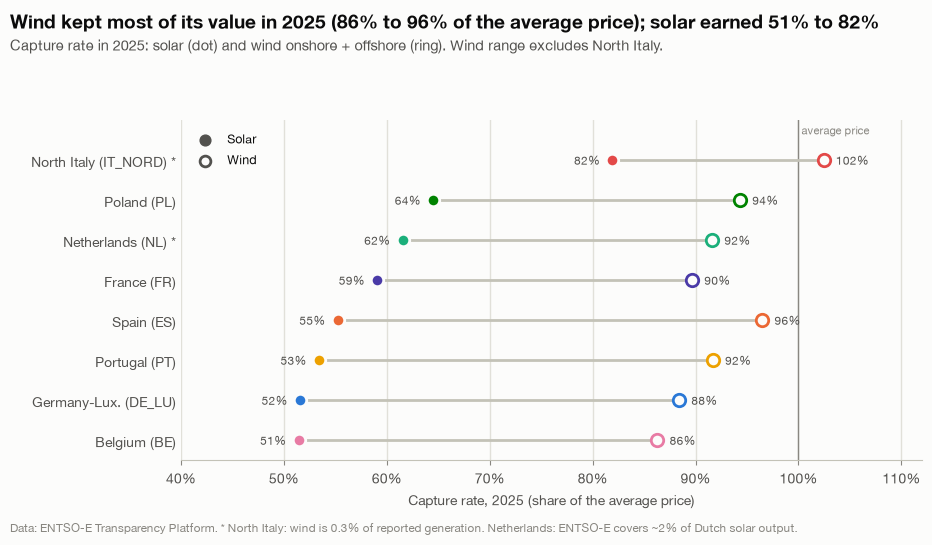

In [4]:
c3 = q2[q2.local_year == 2025].sort_values("solar_capture_rate", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
fig.subplots_adjust(left=0.19, right=0.97, top=0.78, bottom=0.15)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
ax.axvline(1.0, color=cs.INK_MUTED, lw=1, zorder=1)
ax.text(1.0, -0.75, " average price", ha="left", va="center", fontsize=8, color=cs.INK_MUTED)
for i, r in c3.iterrows():
    color = cs.ZONE_COLORS[r.zone]
    ax.plot([r.solar_capture_rate, r.wind_capture_rate], [i, i], color=cs.AXIS, lw=2, zorder=2)
    ax.scatter(r.solar_capture_rate, i, s=80, color=color, edgecolor=cs.SURFACE, linewidth=2, zorder=3)
    ax.scatter(r.wind_capture_rate, i, s=80, facecolor=cs.SURFACE, edgecolor=color, linewidth=2, zorder=3)
    ax.text(r.solar_capture_rate - 0.012, i, f"{r.solar_capture_rate:.0%}", ha="right", va="center",
            fontsize=8.5, color=cs.INK_SECONDARY)
    ax.text(r.wind_capture_rate + 0.012, i, f"{r.wind_capture_rate:.0%}", ha="left", va="center",
            fontsize=8.5, color=cs.INK_SECONDARY)
labels = [f"{cs.ZONE_LABELS[z]} ({z})" + (" *" if z in ("NL", "IT_NORD") else "") for z in c3.zone]
ax.set_yticks(range(len(c3)), labels)
ax.set_ylim(len(c3) - 0.5, -1.0)  # top row first, with room for the reference label
ax.tick_params(axis="y", length=0, labelsize=10)
ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0.4, 1.12)
ax.set_xlabel("Capture rate, 2025 (share of the average price)")
ax.spines["bottom"].set_color(cs.AXIS)
ax.scatter([], [], s=60, color=cs.INK_SECONDARY, label="Solar")
ax.scatter([], [], s=60, facecolor=cs.SURFACE, edgecolor=cs.INK_SECONDARY, linewidth=2, label="Wind")
ax.legend(loc="upper left", frameon=False, fontsize=9)

wind = c3[c3.wind_share >= 0.01]  # IT_NORD wind is 0.3% of its generation: too small to compare
cs.add_title(
    fig,
    f"Wind kept most of its value in 2025 ({wind.wind_capture_rate.min():.0%} to "
    f"{wind.wind_capture_rate.max():.0%} of the average price); solar earned "
    f"{c3.solar_capture_rate.min():.0%} to {c3.solar_capture_rate.max():.0%}",
    "Capture rate in 2025: solar (dot) and wind onshore + offshore (ring). Wind range excludes North Italy.",
)
it_wind = c3.set_index("zone").wind_share["IT_NORD"]
cs.add_source(fig, f"* North Italy: wind is {it_wind:.1%} of reported generation. Netherlands: {NL_NOTE} output.")
cs.save(fig, "q2_solar_vs_wind_2025")
plt.show()

## Numbers quoted in the findings

In [5]:
cols = ["zone", "local_year", "baseload_price", "solar_capture_price", "solar_capture_rate", "solar_share",
        "wind_capture_price", "wind_capture_rate", "wind_share"]
q2[q2.local_year.isin([2019, 2021, 2022, 2025, 2026])][cols].sort_values(["local_year", "zone"])

,zone,local_year,baseload_price,solar_capture_price,solar_capture_rate,solar_share,wind_capture_price,wind_capture_rate,wind_share
0,BE,2019,39.35,36.23,0.9208,0.0403,35.82,0.9104,0.0918
8,DE_LU,2019,37.67,34.91,0.9267,0.0798,32.80,0.8707,0.2372
16,ES,2019,47.70,48.58,1.0183,0.0585,45.65,0.9570,0.2125
24,FR,2019,39.45,37.76,0.9571,0.0217,37.32,0.9459,0.0620
32,IT_NORD,2019,51.25,50.54,0.9861,0.0543,50.40,0.9834,0.0007
40,NL,2019,41.19,38.79,0.9416,0.0006,40.13,0.9741,0.0618
48,PL,2019,46.20,NaN,NaN,NaN,44.74,0.9685,0.1352
56,PT,2019,47.87,48.76,1.0186,0.0217,45.04,0.9409,0.2741
2,BE,2021,104.12,76.78,0.7374,0.0501,94.26,0.9053,0.1153
10,DE_LU,2021,96.85,75.46,0.7791,0.0906,83.19,0.8590,0.2222


## Check: no en or em dashes in chart text
Same house style as Q1: ranges use "to"; negative numbers use the real minus sign.

In [6]:
DASHES = {"\u2013": "en dash", "\u2014": "em dash"}
svgs = sorted(cs.FIGURES.glob("q2_*.svg"))
assert len(svgs) == 3, svgs
for svg in svgs:
    text = svg.read_text(encoding="utf-8")
    found = [name for char, name in DASHES.items() if char in text]
    assert not found, f"{svg.name} contains: {', '.join(found)}"
print(f"OK: no en/em dashes in {len(svgs)} SVGs:", ", ".join(s.name for s in svgs))

OK: no en/em dashes in 3 SVGs: q2_cannibalisation_curve.svg, q2_solar_capture_rate_by_zone.svg, q2_solar_vs_wind_2025.svg
